In [ ]:
# ANSHRAH SHAIKH
# T112
# TYCS
# CAPSTONE PROJECT - DATA VISUALIZATION WITH POER BI AND TABLEAU

In [ ]:
# ANKITA TIWARI
# T124
# TYCS
# CAPSTONE PROJECT - DATA VISUALIZATION WITH POER BI AND TABLEAU

In [1]:
# BLOCK 1: Load and prepare the weather dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

# Upload CSV
uploaded = files.upload()

# Read dataset
df = pd.read_csv(next(iter(uploaded)))

# Convert time to datetime
df['time'] = pd.to_datetime(df['time'])

# Create useful time columns
df['year'] = df['time'].dt.year
df['month'] = df['time'].dt.month
df['month_name'] = df['time'].dt.strftime('%b')
df['hour'] = df['time'].dt.hour
df['date'] = df['time'].dt.date

# Correct month order
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

df['month_name'] = pd.Categorical(
    df['month_name'],
    categories=month_order,
    ordered=True
)

print("Dataset loaded successfully!")
print("Rows:", len(df))
print("Columns:", len(df.columns))
print("\nCities:", df['city'].unique())

display(df.head())

Saving aws_weather_data.csv to aws_weather_data.csv
Dataset loaded successfully!
Rows: 219120
Columns: 13

Cities: ['Mumbai' 'Delhi' 'Chennai' 'Kolkata' 'Bengaluru']


,time,temperature_2m,relative_humidity_2m,precipitation,surface_pressure,wind_speed_10m,wind_direction_10m,city,year,month,month_name,hour,date
0,2021-01-01 00:00:00,23.1,75,0.0,1010.8,10.2,352,Mumbai,2021,1,Jan,0,2021-01-01
1,2021-01-01 01:00:00,22.8,74,0.0,1010.5,7.2,360,Mumbai,2021,1,Jan,1,2021-01-01
2,2021-01-01 02:00:00,22.3,77,0.0,1009.8,6.2,350,Mumbai,2021,1,Jan,2,2021-01-01
3,2021-01-01 03:00:00,21.8,82,0.0,1009.6,4.7,351,Mumbai,2021,1,Jan,3,2021-01-01
4,2021-01-01 04:00:00,21.4,84,0.0,1009.5,4.7,9,Mumbai,2021,1,Jan,4,2021-01-01


In [2]:
# BLOCK 2: Aesthetic theme

# Main colors
BG = '#0B1020'
CARD = '#11182B'
TEXT = '#F5F7FA'
MUTED = '#AAB4C8'

TEMP = '#4CC9F0'
HUMIDITY = '#72E6C1'
RAIN = '#FF8FA3'
PRESSURE = '#A78BFA'
WIND = '#F9C74F'
ACCENT = '#7DD3FC'

# Global styling
plt.rcParams.update({
    'figure.facecolor': BG,
    'axes.facecolor': CARD,
    'axes.edgecolor': '#27324A',
    'axes.labelcolor': TEXT,
    'axes.titlecolor': TEXT,
    'xtick.color': MUTED,
    'ytick.color': MUTED,
    'text.color': TEXT,
    'font.size': 11,
    'axes.titlesize': 17,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'figure.titlesize': 21
})

sns.set_theme(style="whitegrid")

print("Aesthetic theme ready!")

Aesthetic theme ready!


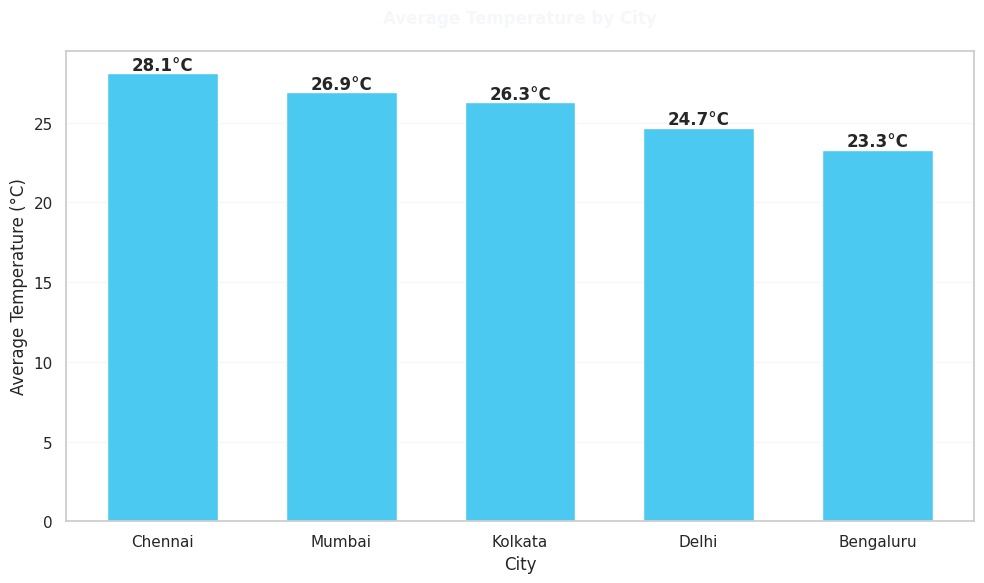

In [3]:
# VISUALIZATION 1: Average Temperature by City

city_temp = (
    df.groupby('city', observed=True)['temperature_2m']
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

bars = plt.bar(
    city_temp.index,
    city_temp.values,
    color=TEMP,
    width=0.62
)

plt.title('Average Temperature by City', pad=20)
plt.xlabel('City')
plt.ylabel('Average Temperature (°C)')

# Add values
for bar, value in zip(bars, city_temp.values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + 0.2,
        f'{value:.1f}°C',
        ha='center',
        fontweight='bold'
    )

plt.grid(axis='y', alpha=0.15)
plt.grid(axis='x', visible=False)

plt.tight_layout()
plt.show()

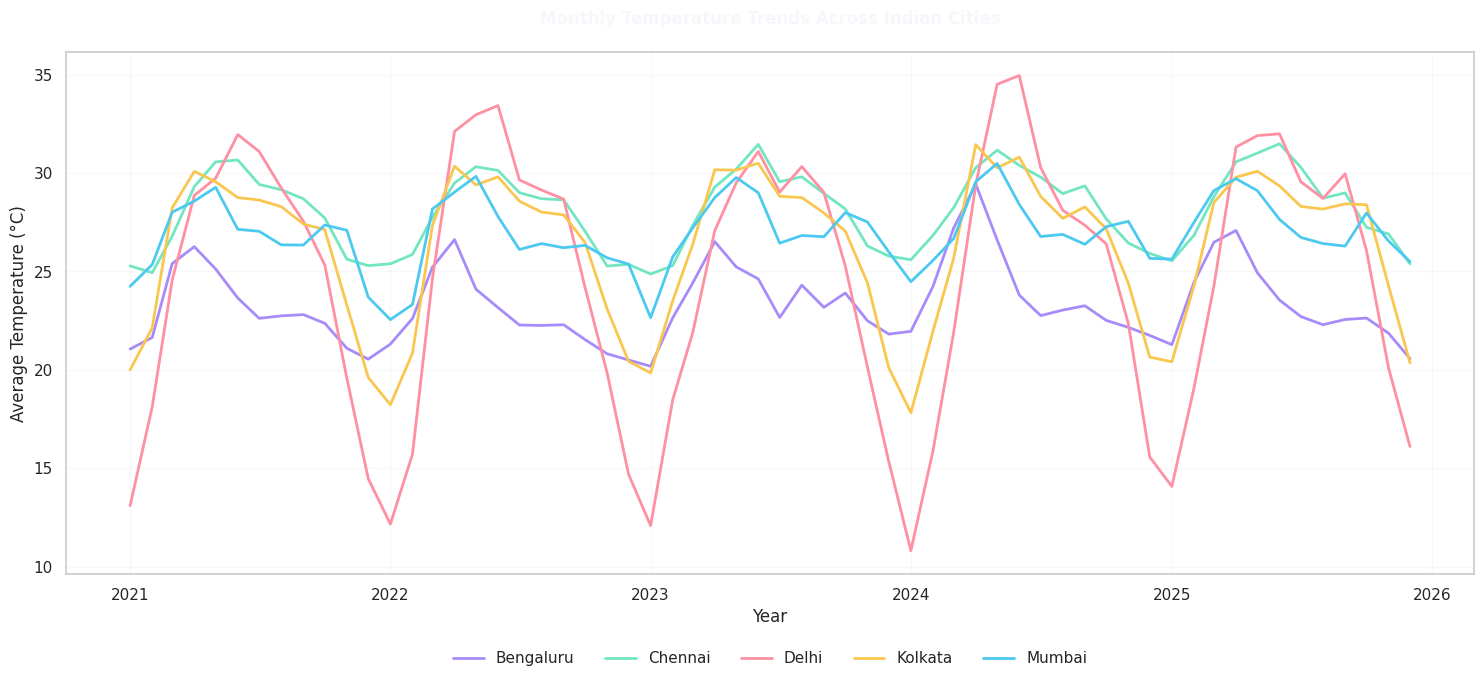

In [4]:
# VISUALIZATION 2: Temperature Trends Over Time

monthly_temp = (
    df.groupby(
        [pd.Grouper(key='time', freq='MS'), 'city'],
        observed=True
    )['temperature_2m']
    .mean()
    .reset_index()
)

plt.figure(figsize=(15, 7))

city_colors = {
    'Mumbai': '#4CC9F0',
    'Delhi': '#FF8FA3',
    'Chennai': '#72E6C1',
    'Bengaluru': '#A78BFA',
    'Kolkata': '#F9C74F'
}

for city in monthly_temp['city'].unique():

    city_data = monthly_temp[monthly_temp['city'] == city]

    plt.plot(
        city_data['time'],
        city_data['temperature_2m'],
        linewidth=2,
        label=city,
        color=city_colors.get(city, ACCENT)
    )

plt.title('Monthly Temperature Trends Across Indian Cities', pad=20)
plt.xlabel('Year')
plt.ylabel('Average Temperature (°C)')

plt.legend(
    frameon=False,
    ncol=5,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.12)
)

plt.grid(alpha=0.12)

plt.tight_layout()
plt.show()

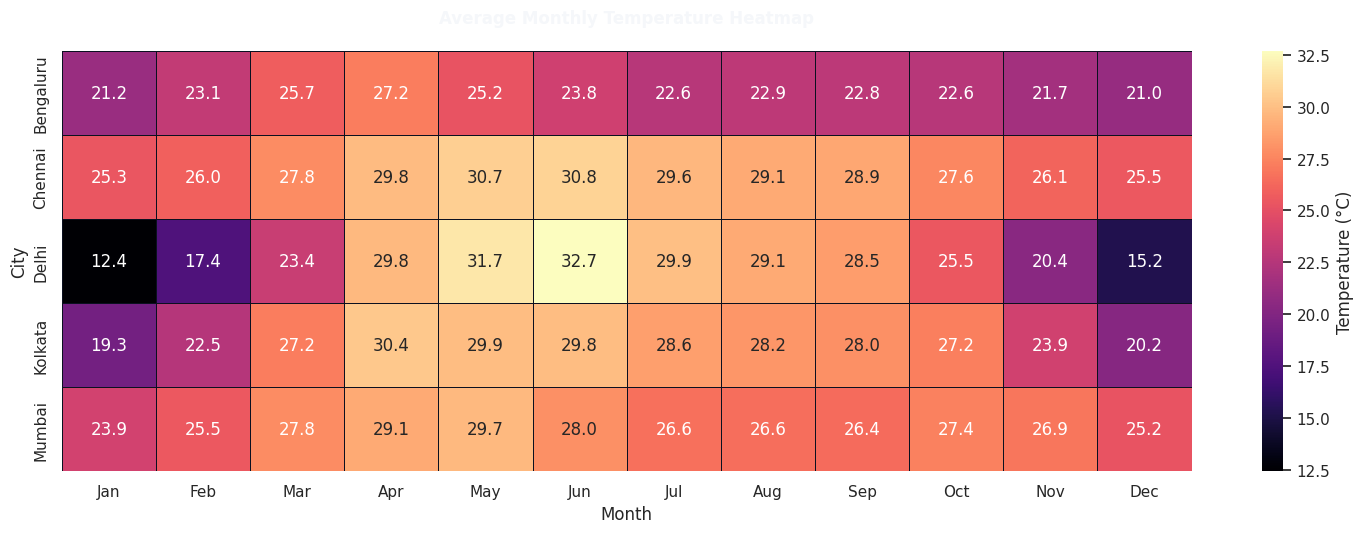

In [5]:
# VISUALIZATION 3: Monthly Temperature Heatmap

heatmap_data = (
    df.groupby(
        ['city', 'month_name'],
        observed=True
    )['temperature_2m']
    .mean()
    .unstack()
)

plt.figure(figsize=(15, 5.5))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.1f',
    cmap='magma',
    linewidths=0.5,
    linecolor=BG,
    cbar_kws={'label': 'Temperature (°C)'}
)

plt.title('Average Monthly Temperature Heatmap', pad=20)
plt.xlabel('Month')
plt.ylabel('City')

plt.tight_layout()
plt.show()

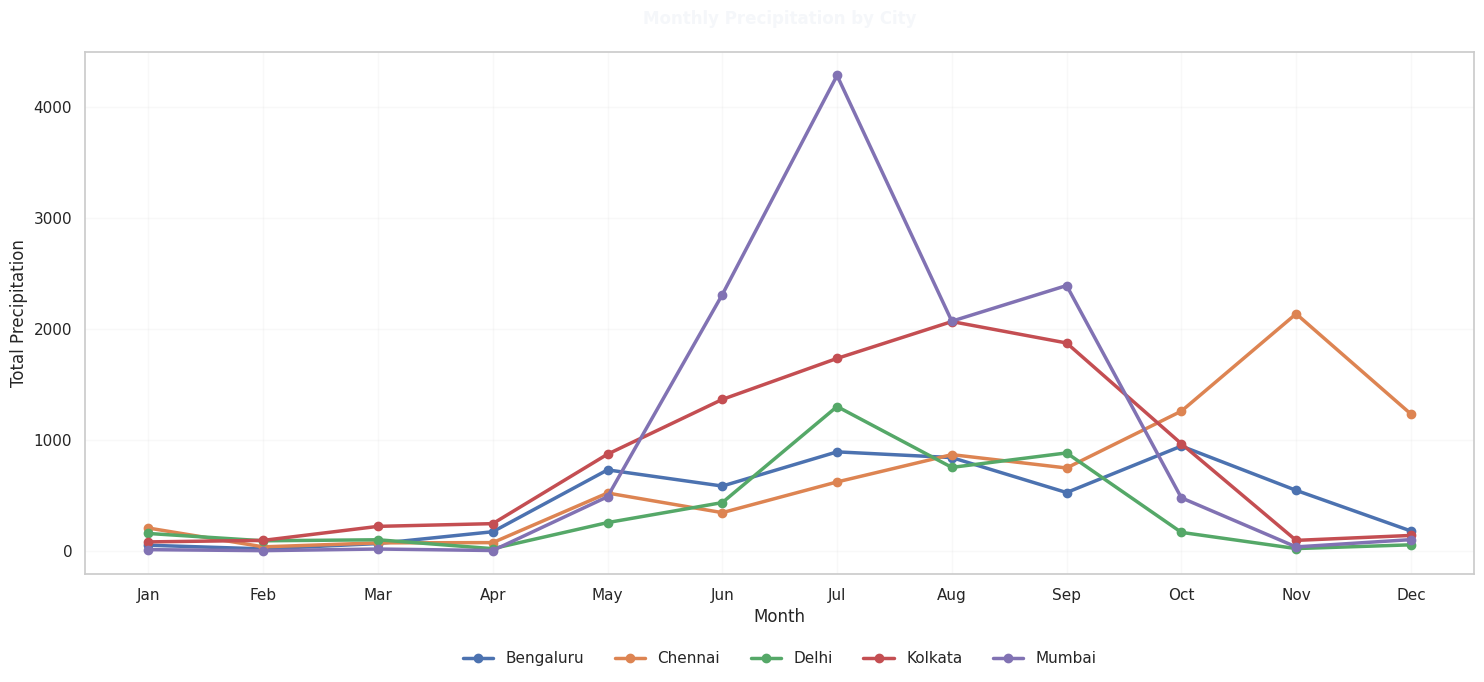

In [6]:
# VISUALIZATION 4: Monthly Precipitation

monthly_rain = (
    df.groupby(
        ['month_name', 'city'],
        observed=True
    )['precipitation']
    .sum()
    .reset_index()
)

plt.figure(figsize=(15, 7))

for city in monthly_rain['city'].unique():

    city_data = monthly_rain[monthly_rain['city'] == city]

    plt.plot(
        city_data['month_name'],
        city_data['precipitation'],
        marker='o',
        linewidth=2.5,
        markersize=6,
        label=city
    )

plt.title('Monthly Precipitation by City', pad=20)
plt.xlabel('Month')
plt.ylabel('Total Precipitation')

plt.legend(
    frameon=False,
    ncol=5,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.12)
)

plt.grid(alpha=0.12)

plt.tight_layout()
plt.show()

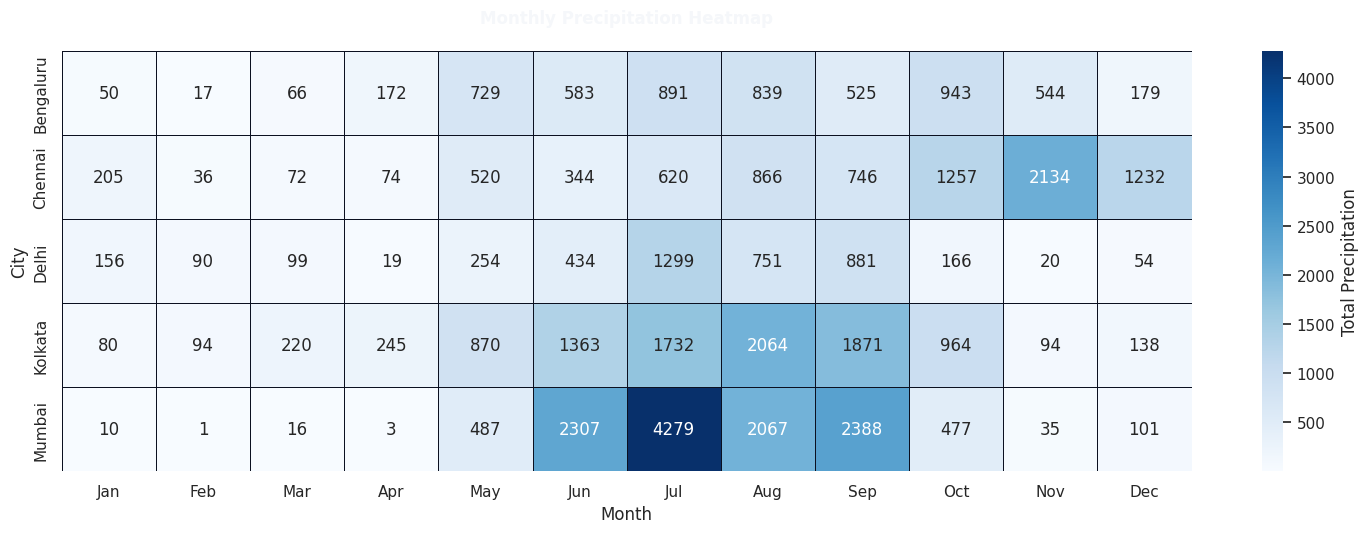

In [7]:
# VISUALIZATION 5: Precipitation Heatmap

rain_heatmap = (
    df.groupby(
        ['city', 'month_name'],
        observed=True
    )['precipitation']
    .sum()
    .unstack()
)

plt.figure(figsize=(15, 5.5))

sns.heatmap(
    rain_heatmap,
    annot=True,
    fmt='.0f',
    cmap='Blues',
    linewidths=0.5,
    linecolor=BG,
    cbar_kws={'label': 'Total Precipitation'}
)

plt.title('Monthly Precipitation Heatmap', pad=20)
plt.xlabel('Month')
plt.ylabel('City')

plt.tight_layout()
plt.show()

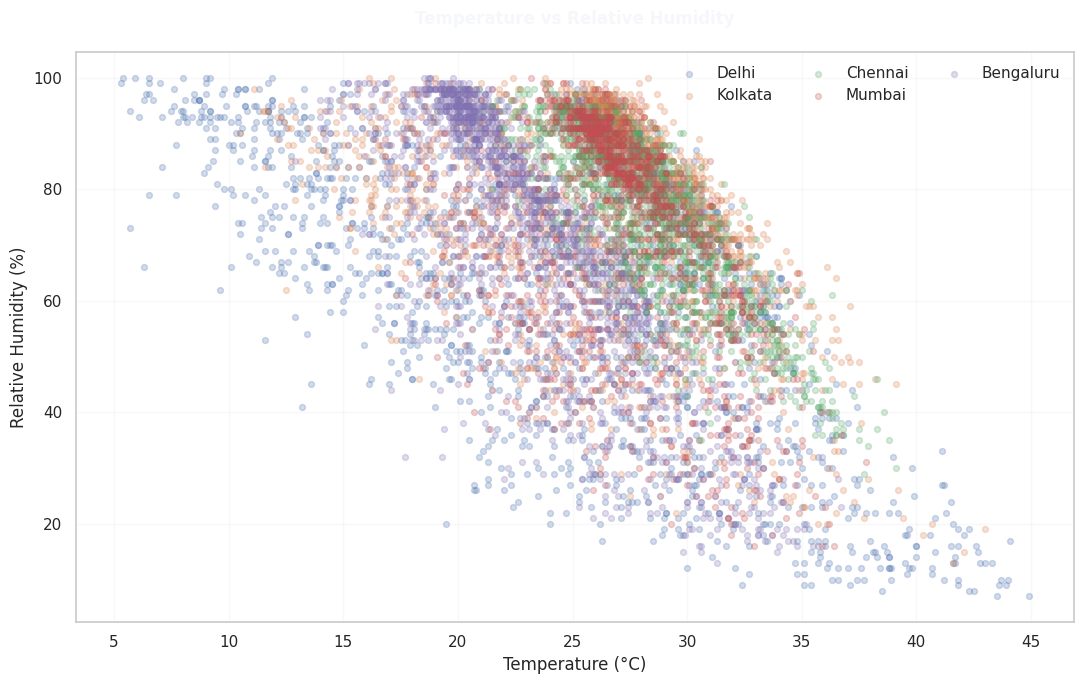

In [8]:
# VISUALIZATION 6: Temperature vs Humidity

sample = df.sample(
    min(8000, len(df)),
    random_state=42
)

plt.figure(figsize=(11, 7))

for city in sample['city'].unique():

    city_data = sample[sample['city'] == city]

    plt.scatter(
        city_data['temperature_2m'],
        city_data['relative_humidity_2m'],
        alpha=0.25,
        s=18,
        label=city
    )

plt.title('Temperature vs Relative Humidity', pad=20)
plt.xlabel('Temperature (°C)')
plt.ylabel('Relative Humidity (%)')

plt.legend(
    frameon=False,
    ncol=3
)

plt.grid(alpha=0.12)

plt.tight_layout()
plt.show()

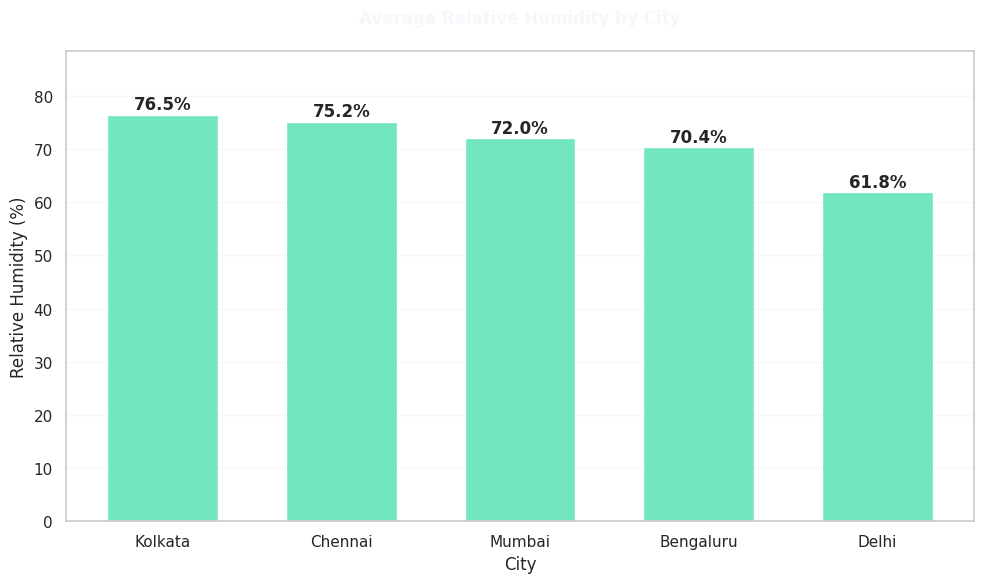

In [9]:
# VISUALIZATION 7: Average Humidity by City

city_humidity = (
    df.groupby('city', observed=True)['relative_humidity_2m']
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

bars = plt.bar(
    city_humidity.index,
    city_humidity.values,
    color=HUMIDITY,
    width=0.62
)

plt.title('Average Relative Humidity by City', pad=20)
plt.xlabel('City')
plt.ylabel('Relative Humidity (%)')

for bar, value in zip(bars, city_humidity.values):

    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + 1,
        f'{value:.1f}%',
        ha='center',
        fontweight='bold'
    )

plt.ylim(0, max(city_humidity.values) + 12)

plt.grid(axis='y', alpha=0.15)
plt.grid(axis='x', visible=False)

plt.tight_layout()
plt.show()

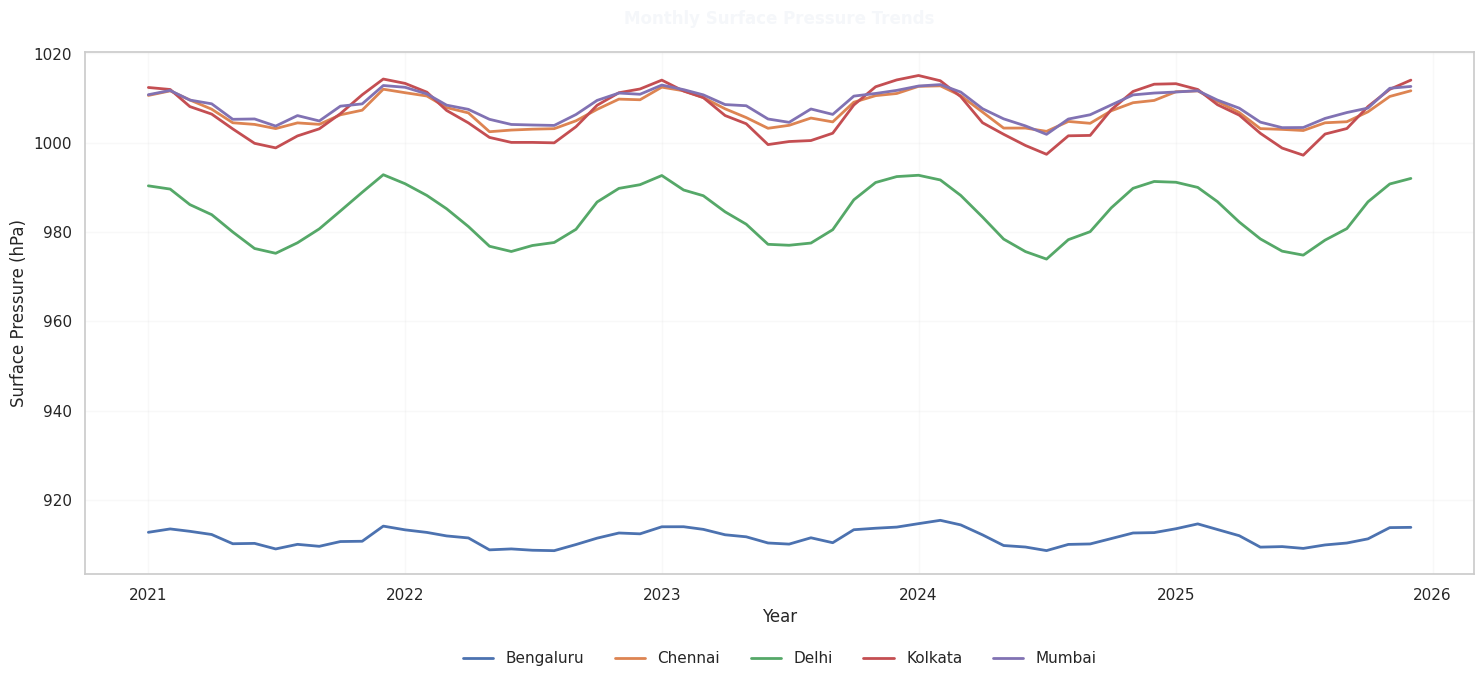

In [10]:
# VISUALIZATION 8: Surface Pressure Trends

monthly_pressure = (
    df.groupby(
        [pd.Grouper(key='time', freq='MS'), 'city'],
        observed=True
    )['surface_pressure']
    .mean()
    .reset_index()
)

plt.figure(figsize=(15, 7))

for city in monthly_pressure['city'].unique():

    city_data = monthly_pressure[
        monthly_pressure['city'] == city
    ]

    plt.plot(
        city_data['time'],
        city_data['surface_pressure'],
        linewidth=2,
        label=city
    )

plt.title('Monthly Surface Pressure Trends', pad=20)
plt.xlabel('Year')
plt.ylabel('Surface Pressure (hPa)')

plt.legend(
    frameon=False,
    ncol=5,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.12)
)

plt.grid(alpha=0.12)

plt.tight_layout()
plt.show()

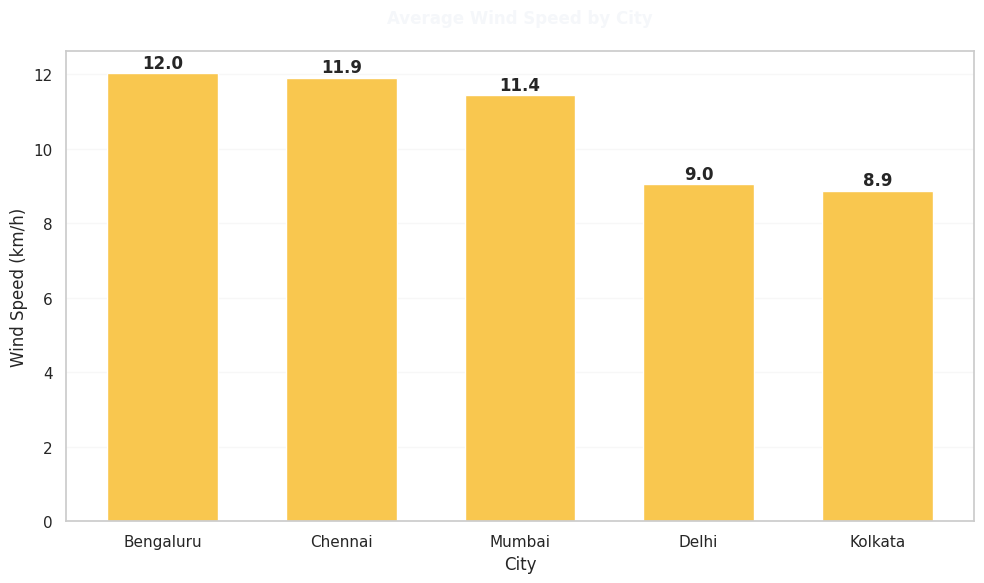

In [11]:
# VISUALIZATION 9: Average Wind Speed by City

city_wind = (
    df.groupby('city', observed=True)['wind_speed_10m']
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

bars = plt.bar(
    city_wind.index,
    city_wind.values,
    color=WIND,
    width=0.62
)

plt.title('Average Wind Speed by City', pad=20)
plt.xlabel('City')
plt.ylabel('Wind Speed (km/h)')

for bar, value in zip(bars, city_wind.values):

    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + 0.15,
        f'{value:.1f}',
        ha='center',
        fontweight='bold'
    )

plt.grid(axis='y', alpha=0.15)
plt.grid(axis='x', visible=False)

plt.tight_layout()
plt.show()

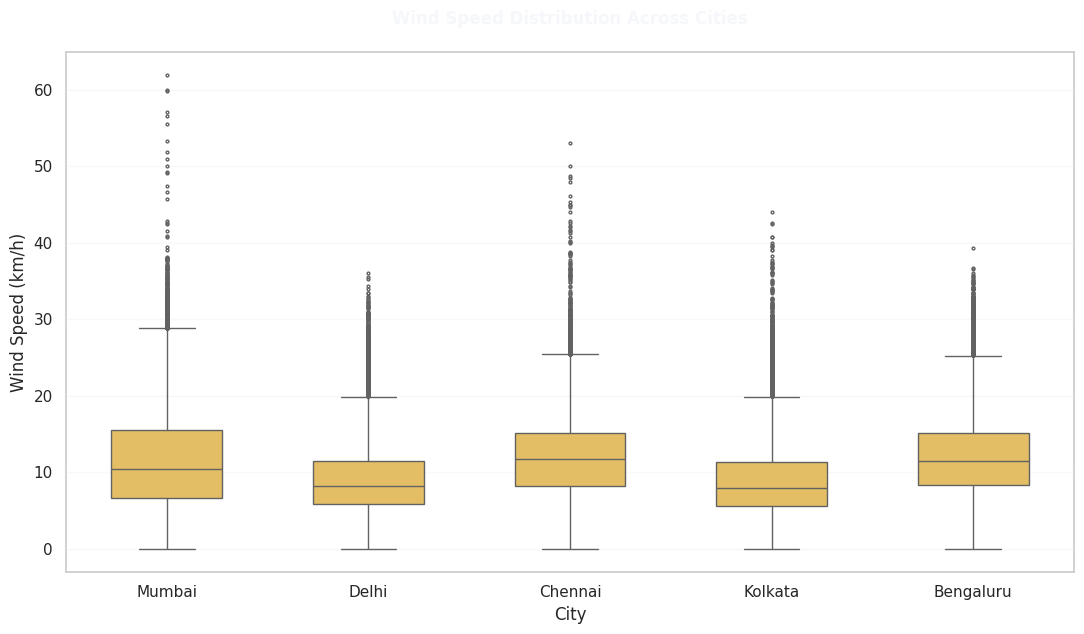

In [12]:
# VISUALIZATION 10: Wind Speed Distribution

plt.figure(figsize=(11, 6.5))

sns.boxplot(
    data=df,
    x='city',
    y='wind_speed_10m',
    color=WIND,
    width=0.55,
    fliersize=2
)

plt.title('Wind Speed Distribution Across Cities', pad=20)
plt.xlabel('City')
plt.ylabel('Wind Speed (km/h)')

plt.grid(axis='y', alpha=0.12)
plt.grid(axis='x', visible=False)

plt.tight_layout()
plt.show()

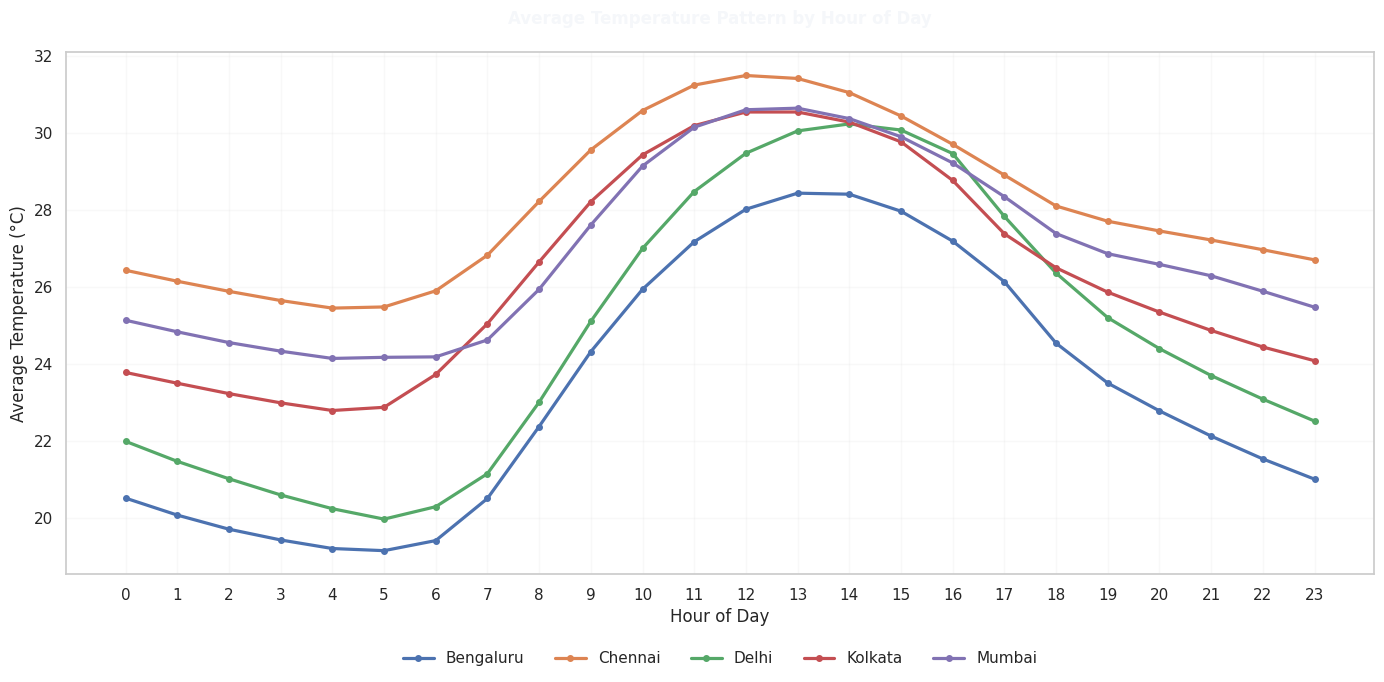

In [13]:
# VISUALIZATION 11: Hourly Temperature Pattern

hourly_temp = (
    df.groupby(
        ['hour', 'city'],
        observed=True
    )['temperature_2m']
    .mean()
    .reset_index()
)

plt.figure(figsize=(14, 7))

for city in hourly_temp['city'].unique():

    city_data = hourly_temp[
        hourly_temp['city'] == city
    ]

    plt.plot(
        city_data['hour'],
        city_data['temperature_2m'],
        marker='o',
        linewidth=2.3,
        markersize=4,
        label=city
    )

plt.title('Average Temperature Pattern by Hour of Day', pad=20)
plt.xlabel('Hour of Day')
plt.ylabel('Average Temperature (°C)')

plt.xticks(range(0, 24))

plt.legend(
    frameon=False,
    ncol=5,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.12)
)

plt.grid(alpha=0.12)

plt.tight_layout()
plt.show()

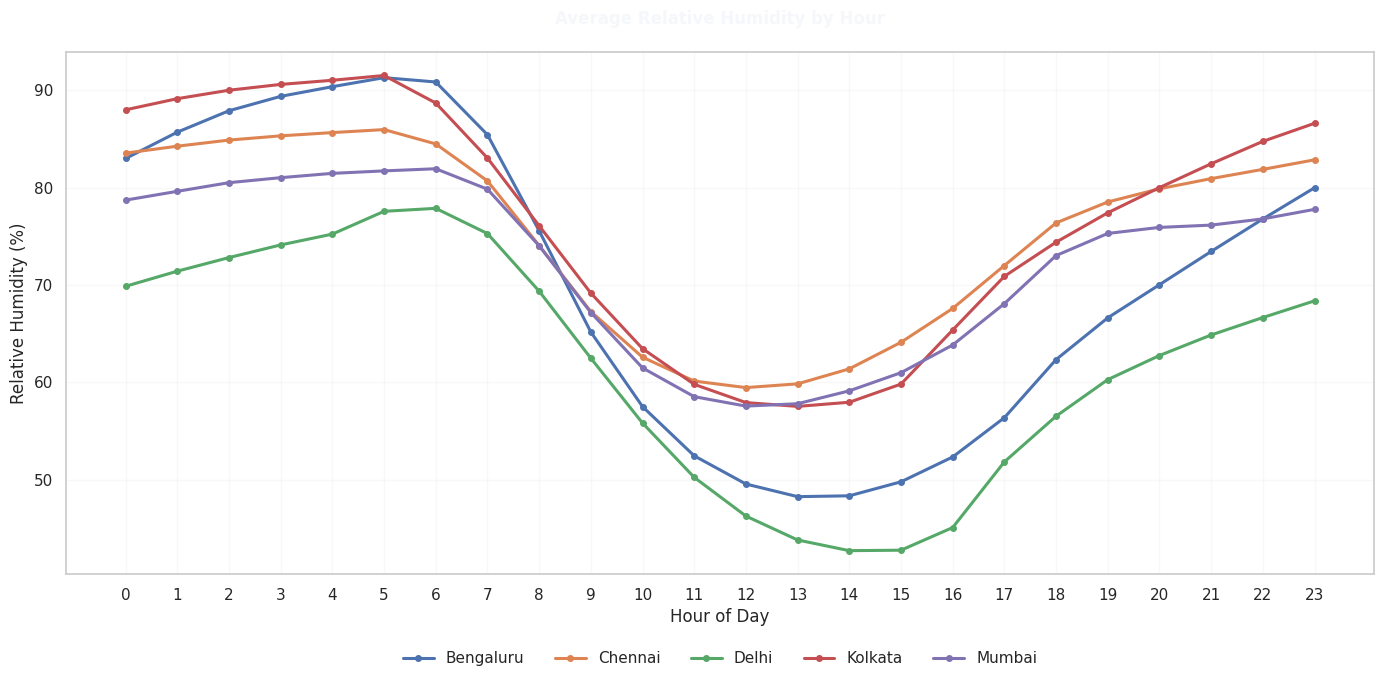

In [14]:
# VISUALIZATION 12: Hourly Humidity Pattern

hourly_humidity = (
    df.groupby(
        ['hour', 'city'],
        observed=True
    )['relative_humidity_2m']
    .mean()
    .reset_index()
)

plt.figure(figsize=(14, 7))

for city in hourly_humidity['city'].unique():

    city_data = hourly_humidity[
        hourly_humidity['city'] == city
    ]

    plt.plot(
        city_data['hour'],
        city_data['relative_humidity_2m'],
        marker='o',
        linewidth=2.2,
        markersize=4,
        label=city
    )

plt.title('Average Relative Humidity by Hour', pad=20)
plt.xlabel('Hour of Day')
plt.ylabel('Relative Humidity (%)')

plt.xticks(range(0, 24))

plt.legend(
    frameon=False,
    ncol=5,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.12)
)

plt.grid(alpha=0.12)

plt.tight_layout()
plt.show()

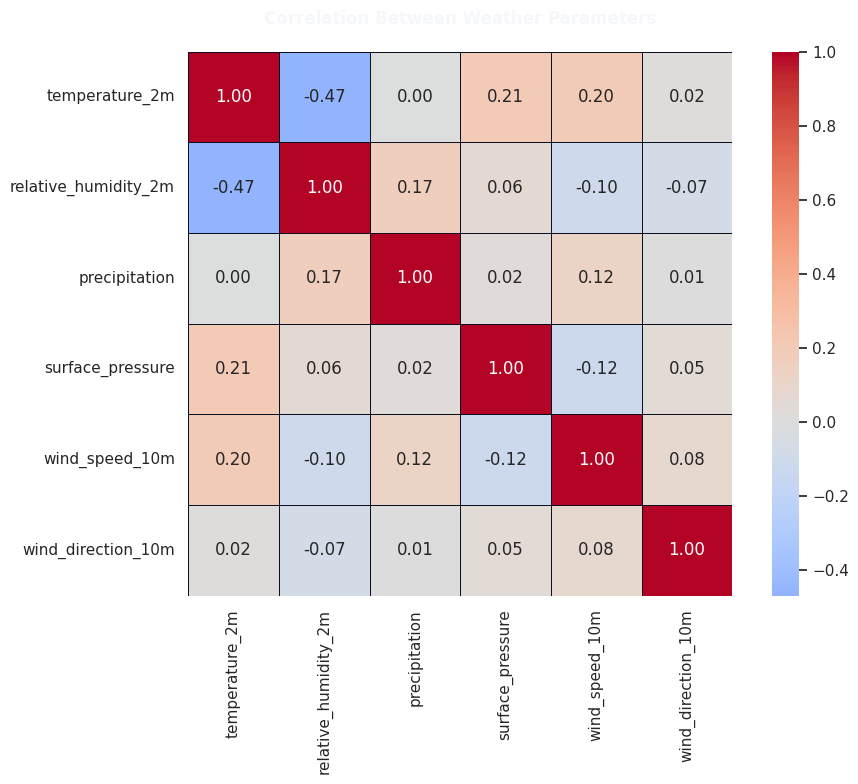

In [15]:
# VISUALIZATION 13: Weather Parameter Correlation Matrix

numeric_columns = [
    'temperature_2m',
    'relative_humidity_2m',
    'precipitation',
    'surface_pressure',
    'wind_speed_10m',
    'wind_direction_10m'
]

corr = df[numeric_columns].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    linecolor=BG,
    square=True
)

plt.title('Correlation Between Weather Parameters', pad=20)

plt.tight_layout()
plt.show()

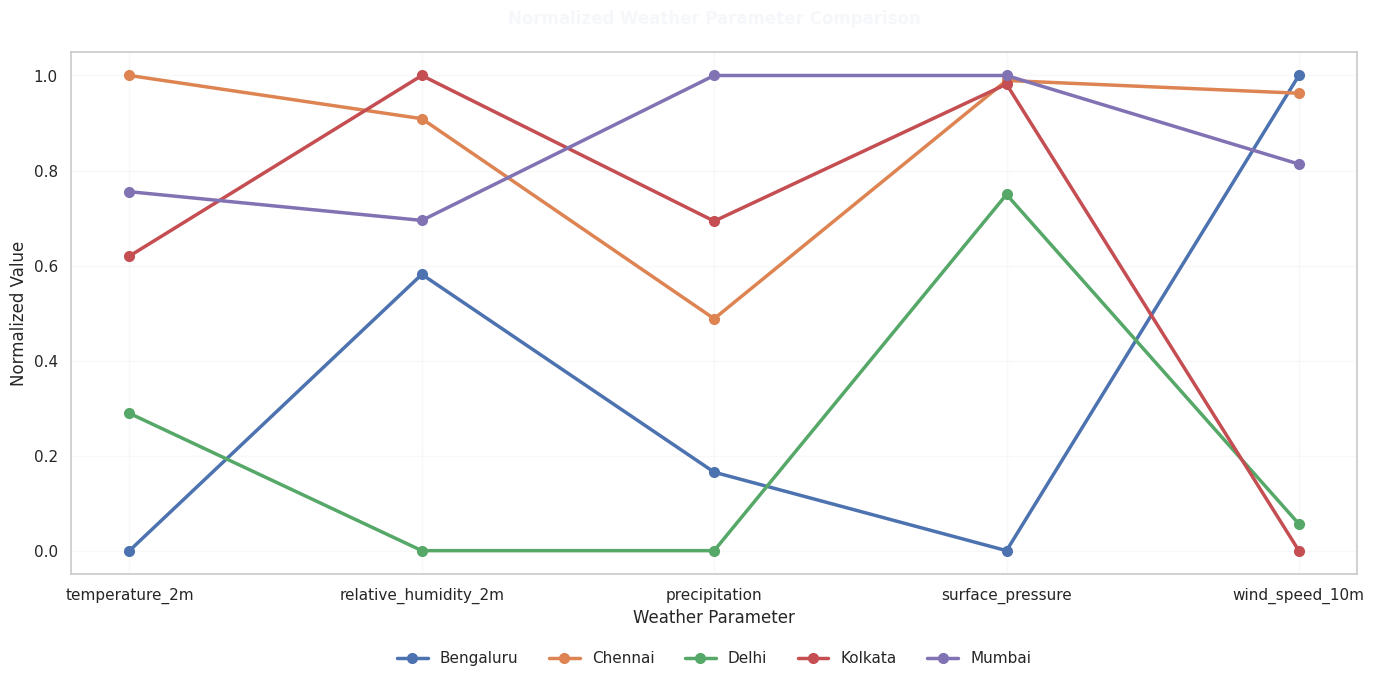

In [16]:
# VISUALIZATION 14: Normalized Weather Parameter Comparison

from sklearn.preprocessing import MinMaxScaler

parameters = [
    'temperature_2m',
    'relative_humidity_2m',
    'precipitation',
    'surface_pressure',
    'wind_speed_10m'
]

city_average = (
    df.groupby('city', observed=True)[parameters]
      .mean()
)

scaler = MinMaxScaler()

normalized = pd.DataFrame(
    scaler.fit_transform(city_average),
    columns=parameters,
    index=city_average.index
)

plt.figure(figsize=(14, 7))

for city in normalized.index:

    plt.plot(
        normalized.columns,
        normalized.loc[city],
        marker='o',
        linewidth=2.5,
        markersize=7,
        label=city
    )

plt.title(
    'Normalized Weather Parameter Comparison',
    pad=20
)

plt.xlabel('Weather Parameter')
plt.ylabel('Normalized Value')

plt.legend(
    frameon=False,
    ncol=5,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.12)
)

plt.grid(alpha=0.12)

plt.tight_layout()
plt.show()

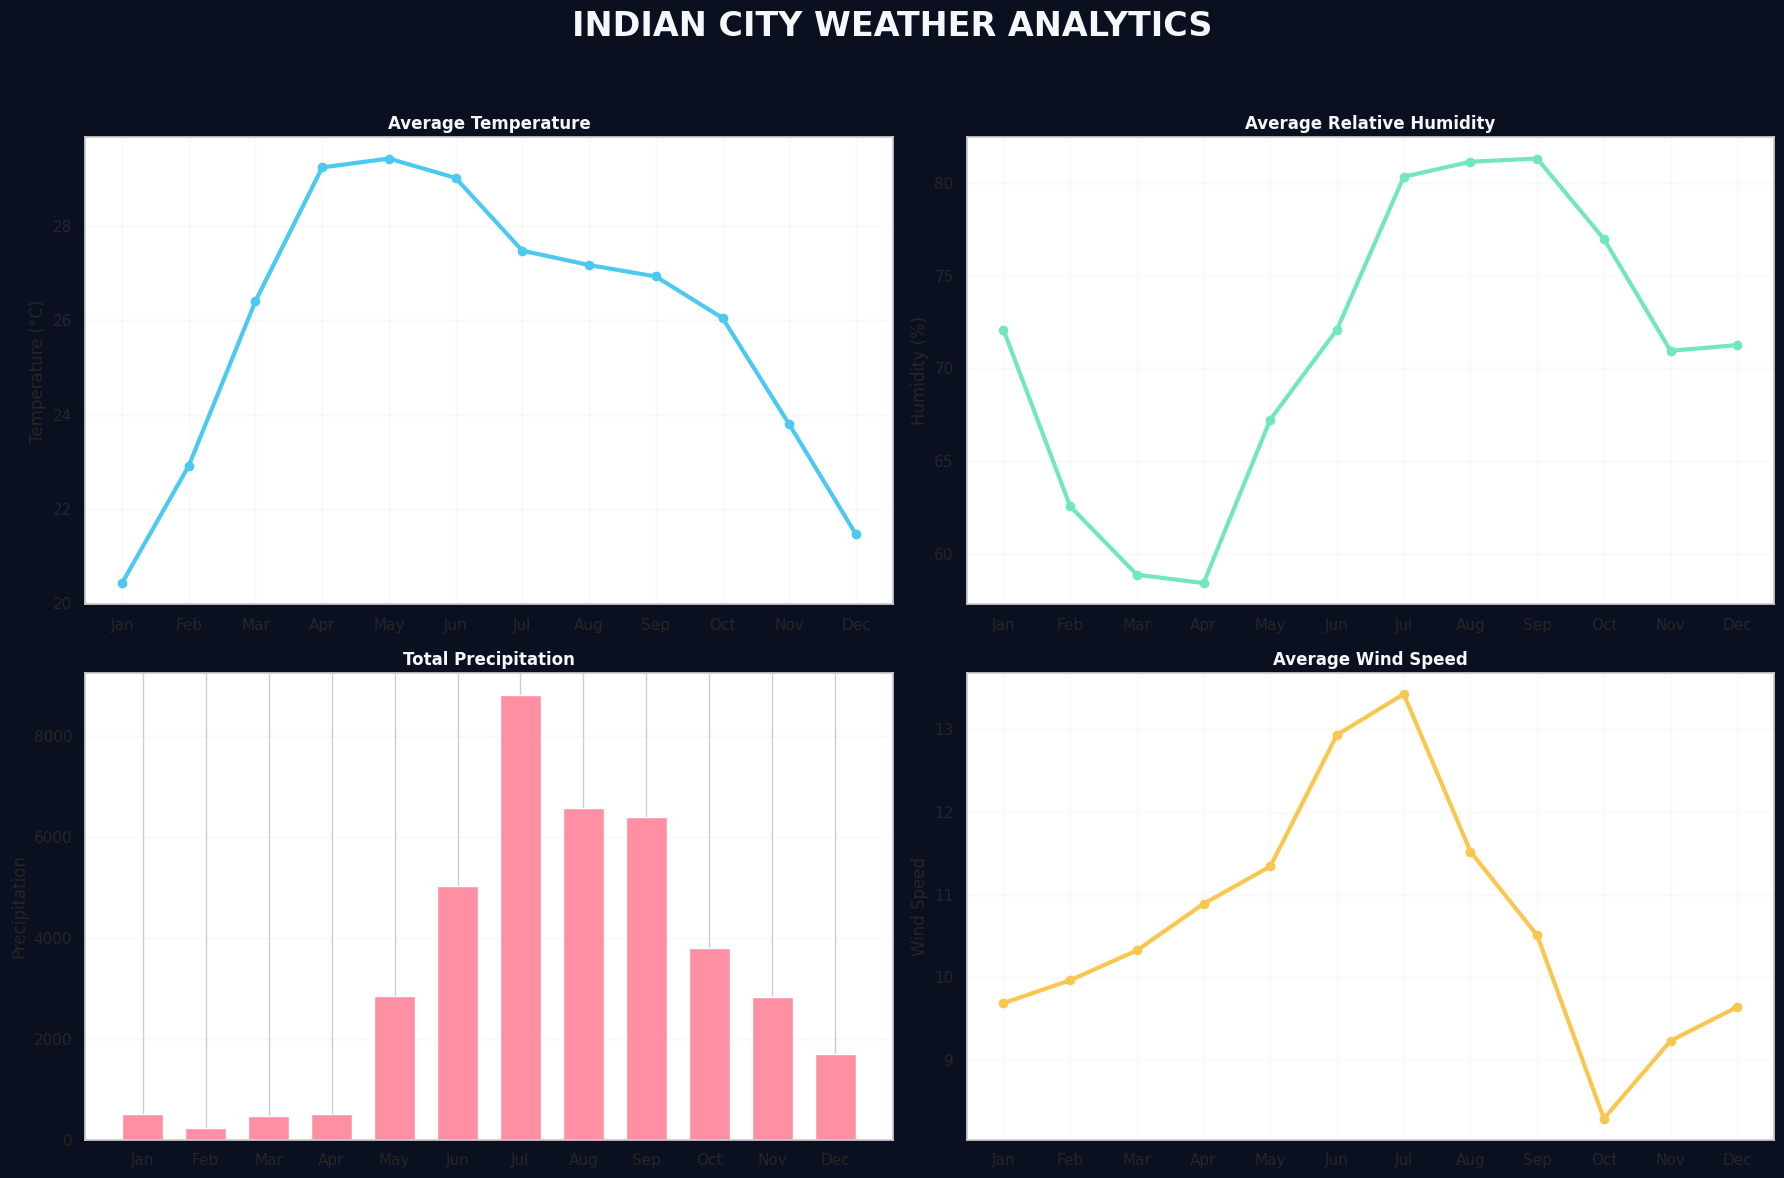

In [17]:
# VISUALIZATION 15: Weather Dashboard

fig, axes = plt.subplots(
    2, 2,
    figsize=(18, 12)
)

fig.patch.set_facecolor(BG)

# -------------------------
# Temperature
# -------------------------

monthly_temperature = (
    df.groupby('month_name', observed=True)['temperature_2m']
      .mean()
)

axes[0, 0].plot(
    monthly_temperature.index,
    monthly_temperature.values,
    marker='o',
    linewidth=3,
    color=TEMP
)

axes[0, 0].set_title('Average Temperature')
axes[0, 0].set_ylabel('Temperature (°C)')
axes[0, 0].grid(alpha=0.12)


# -------------------------
# Humidity
# -------------------------

monthly_humidity = (
    df.groupby('month_name', observed=True)['relative_humidity_2m']
      .mean()
)

axes[0, 1].plot(
    monthly_humidity.index,
    monthly_humidity.values,
    marker='o',
    linewidth=3,
    color=HUMIDITY
)

axes[0, 1].set_title('Average Relative Humidity')
axes[0, 1].set_ylabel('Humidity (%)')
axes[0, 1].grid(alpha=0.12)


# -------------------------
# Precipitation
# -------------------------

monthly_precipitation = (
    df.groupby('month_name', observed=True)['precipitation']
      .sum()
)

axes[1, 0].bar(
    monthly_precipitation.index,
    monthly_precipitation.values,
    color=RAIN,
    width=0.65
)

axes[1, 0].set_title('Total Precipitation')
axes[1, 0].set_ylabel('Precipitation')
axes[1, 0].grid(axis='y', alpha=0.12)


# -------------------------
# Wind
# -------------------------

monthly_wind = (
    df.groupby('month_name', observed=True)['wind_speed_10m']
      .mean()
)

axes[1, 1].plot(
    monthly_wind.index,
    monthly_wind.values,
    marker='o',
    linewidth=3,
    color=WIND
)

axes[1, 1].set_title('Average Wind Speed')
axes[1, 1].set_ylabel('Wind Speed')
axes[1, 1].grid(alpha=0.12)


# -------------------------
# Overall title
# -------------------------

fig.suptitle(
    'INDIAN CITY WEATHER ANALYTICS',
    fontsize=24,
    fontweight='bold',
    color=TEXT,
    y=0.98
)

plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.show()

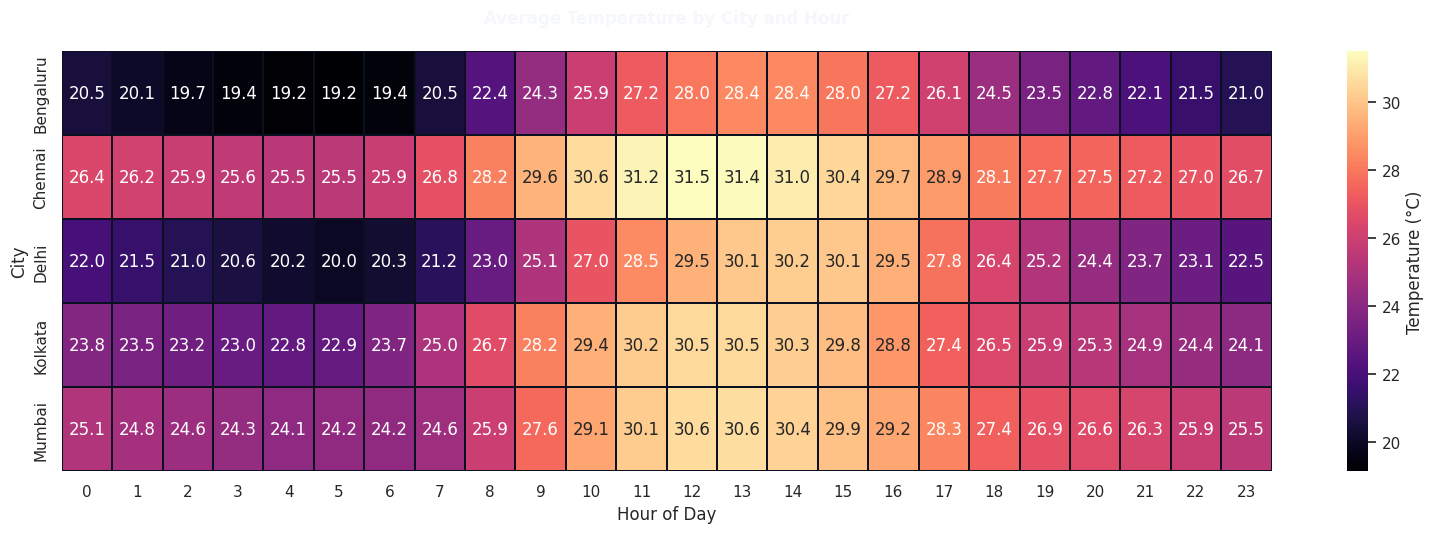

In [18]:
# VISUALIZATION 16: City × Hour Temperature Heatmap

hour_heatmap = (
    df.groupby(
        ['city', 'hour'],
        observed=True
    )['temperature_2m']
    .mean()
    .unstack()
)

plt.figure(figsize=(16, 5.5))

sns.heatmap(
    hour_heatmap,
    cmap='magma',
    annot=True,
    fmt='.1f',
    linewidths=0.3,
    linecolor=BG,
    cbar_kws={'label': 'Temperature (°C)'}
)

plt.title(
    'Average Temperature by City and Hour',
    pad=20
)

plt.xlabel('Hour of Day')
plt.ylabel('City')

plt.tight_layout()
plt.show()

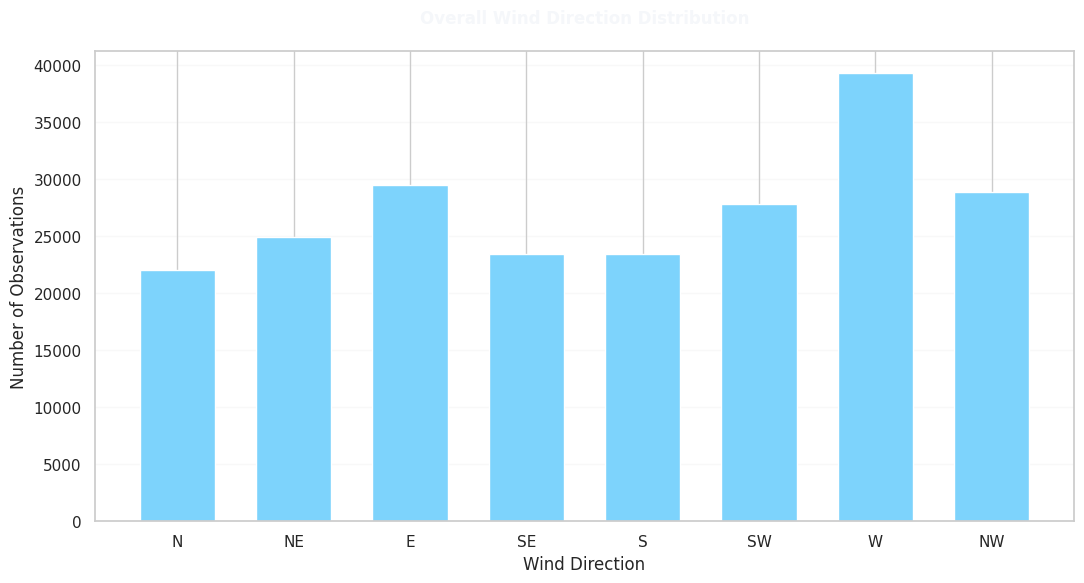

In [19]:
# VISUALIZATION 17: Wind Direction Distribution

# Convert degrees into compass directions
def compass_direction(degree):

    directions = [
        'N', 'NE', 'E', 'SE',
        'S', 'SW', 'W', 'NW'
    ]

    index = int((degree + 22.5) // 45) % 8

    return directions[index]


df['wind_direction_compass'] = (
    df['wind_direction_10m']
    .apply(compass_direction)
)

direction_order = [
    'N', 'NE', 'E', 'SE',
    'S', 'SW', 'W', 'NW'
]

direction_counts = (
    df['wind_direction_compass']
    .value_counts()
    .reindex(direction_order)
)

plt.figure(figsize=(11, 6))

bars = plt.bar(
    direction_counts.index,
    direction_counts.values,
    color=ACCENT,
    width=0.65
)

plt.title('Overall Wind Direction Distribution', pad=20)
plt.xlabel('Wind Direction')
plt.ylabel('Number of Observations')

plt.grid(axis='y', alpha=0.12)

plt.tight_layout()
plt.show()